# data cleaning

### imports

In [441]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [442]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.preprocessing import StandardScaler


# import 'Pandas' 
import pandas as pd 

# import 'Numpy' 
import numpy as np

# import subpackage of Matplotlib
import matplotlib.pyplot as plt

# import 'Seaborn' 
import seaborn as sns

# to suppress warnings 
from warnings import filterwarnings
filterwarnings('ignore')

# display all columns of the dataframe
pd.options.display.max_columns = None

# display all rows of the dataframe
pd.options.display.max_rows = None
 
# to display the float values upto 6 decimal places     
pd.options.display.float_format = '{:.6f}'.format

# import train-test split 
from sklearn.model_selection import train_test_split

# # import various functions from statsmodels
# import statsmodels
import statsmodels.api as sm
# import statsmodels.stats.api as sms
# from statsmodels.graphics.gofplots import qqplot

# # import 'stats'
# from scipy import stats

# # 'metrics' from sklearn is used for evaluating the model performance
# from sklearn.metrics import mean_squared_error

# # import functions to perform feature selection
# from mlxtend.feature_selection import SequentialFeatureSelector as sfs
# #from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import RFE

# import function to perform linear regression
from sklearn.linear_model import LinearRegression

# import functions to perform cross validation
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold



from sklearn.neighbors import KNeighborsRegressor


# from thefuzz import process
# from difflib import get_close_matches

from xgboost import XGBClassifier


from xgboost import XGBRegressor
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


import matplotlib.pyplot as plt
from xgboost import plot_importance

In [443]:
"""
# Geocoding using GoogleV3
# this has been done and saved for future steps
# so that we don't exhaust the API calls limit
# this code is just for reference

# the code takes location names and generates location coordinates



train = pd.read_csv('train_(2)_(1)_(1)_(1).csv')
test = pd.read_csv('test_(2)_(1)_(1)_(1).csv')
avgRent = pd.read_csv('avg_rent_(1)_(1)_(1)_(1).csv')
disCityCenter = pd.read_csv('dist_from_city_centre_(1)_(1)_(1)_(1).csv')
sampleSubmission = pd.read_csv('sample_submission_(3)_(1)_(1)_(1).csv')

geolocator = GoogleV3(api_key="private key taken from gcp")


def geocodeFn(name):
    try:
        location = geolocator.geocode("bangalore " + name)
        return f'{location.latitude}, {location.longitude}'
    except:
        print("Error in geocoding for location:", name)
        return (np.nan, np.nan)


test['coordinates'] = test['location'].apply(lambda x: geocodeFn(x))
test[['latitude', 'longitude']] = test.coordinates.str.split(", ",expand=True)
test.to_csv("test.csv")

train.dropna(subset=['location'],inplace=True)
train['coordinates'] = train['location'].apply(lambda x: geocodeFn(x))
train[['latitude', 'longitude']] = train.coordinates.str.split(", ",expand=True)
train.to_csv("train.csv")

avgRent['coordinates'] = avgRent['location'].apply(lambda x: geocodeFn(x))
avgRent[['latitude', 'longitude']] = avgRent.coordinates.str.split(", ",expand=True)
avgRent.to_csv("avgRent.csv")

disCityCenter['coordinates'] = disCityCenter['location'].apply(lambda x: geocodeFn(x))
disCityCenter[['latitude', 'longitude']] = disCityCenter.coordinates.str.split(", ",expand=True)
disCityCenter.to_csv("disCityCenter.csv")


"""


'\n# Geocoding using GoogleV3\n# this has been done and saved for future steps\n# so that we don\'t exhaust the API calls limit\n# this code is just for reference\n\n# the code takes location names and generates location coordinates\n\n\n\ntrain = pd.read_csv(\'train_(2)_(1)_(1)_(1).csv\')\ntest = pd.read_csv(\'test_(2)_(1)_(1)_(1).csv\')\navgRent = pd.read_csv(\'avg_rent_(1)_(1)_(1)_(1).csv\')\ndisCityCenter = pd.read_csv(\'dist_from_city_centre_(1)_(1)_(1)_(1).csv\')\nsampleSubmission = pd.read_csv(\'sample_submission_(3)_(1)_(1)_(1).csv\')\n\ngeolocator = GoogleV3(api_key="private key taken from gcp")\n\n\ndef geocodeFn(name):\n    try:\n        location = geolocator.geocode("bangalore " + name)\n        return f\'{location.latitude}, {location.longitude}\'\n    except:\n        print("Error in geocoding for location:", name)\n        return (np.nan, np.nan)\n\n\ntest[\'coordinates\'] = test[\'location\'].apply(lambda x: geocodeFn(x))\ntest[[\'latitude\', \'longitude\']] = test.coor

In [444]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
avgRent = pd.read_csv('avgRent.csv')
disCityCenter = pd.read_csv('disCityCenter.csv')

### null values

In [445]:
train.drop(['Unnamed: 0'], axis=1, inplace=True)
test.drop(['Unnamed: 0'], axis=1, inplace=True)
avgRent.drop(['Unnamed: 0'], axis=1, inplace=True)
disCityCenter.drop(['Unnamed: 0'], axis=1, inplace=True)

In [446]:
print(test.info())
# test.dropna(subset=['size', 'location', 'bath', 'balcony'], inplace=True)
# test['size'].fillna(test['size'].mode(), inplace=True)

test['size'].fillna('2 BHK', inplace=True)
test['bath'].fillna(test['bath'].median(), inplace=True)
test['balcony'].fillna(test['balcony'].median(), inplace=True)
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2664 entries, 0 to 2663
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            2664 non-null   int64  
 1   area_type     2664 non-null   object 
 2   availability  2664 non-null   object 
 3   location      2664 non-null   object 
 4   size          2662 non-null   object 
 5   society       1590 non-null   object 
 6   total_sqft    2664 non-null   object 
 7   bath          2656 non-null   float64
 8   balcony       2559 non-null   float64
 9   coordinates   2664 non-null   object 
 10  latitude      2664 non-null   float64
 11  longitude     2664 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 249.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2664 entries, 0 to 2663
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            2664 non-n

In [447]:



print(train.info())
train.dropna(subset=['size', 'location', 'bath', 'balcony'], inplace=True)
print(train.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10655 entries, 0 to 10654
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            10655 non-null  int64  
 1   area_type     10655 non-null  object 
 2   availability  10655 non-null  object 
 3   location      10655 non-null  object 
 4   size          10641 non-null  object 
 5   society       6227 non-null   object 
 6   total_sqft    10655 non-null  object 
 7   bath          10590 non-null  float64
 8   balcony       10151 non-null  float64
 9   price         10655 non-null  float64
 10  coordinates   10655 non-null  object 
 11  latitude      10655 non-null  float64
 12  longitude     10655 non-null  float64
dtypes: float64(5), int64(1), object(7)
memory usage: 1.1+ MB
None
<class 'pandas.core.frame.DataFrame'>
Index: 10151 entries, 0 to 10654
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        -------------

### cleaning total_sqft and making it numeric 

In [448]:
# as it is expected to be in sq feet
# then scaling it

def is_number(x):
    try:
        float(x)
        return True
    except ValueError:
        return False

def return_sqft(x):
    if is_number(x):
        return float(x)
    
    tokens = x.split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    if x.endswith('Sq. Meter') or x.endswith('Sq. Meter'):
        x = float(x.split('Sq')[0])
        return x*10.7639
    if x.endswith('Acres'):
        x = float(x.split('Acr')[0])
        return x*43560
    if x.endswith('Sq. Yards'):
        x = float(x.split('Sq')[0])
        return x*10.7639
    if x.endswith('Grounds'):
        x = float(x.split('Gro')[0])
        return x*2400
    if x.endswith('Cents'):
        x = float(x.split('Cen')[0])
        return x*435.6
    if x.endswith('Perch'):
        x = float(x.split('Per')[0])
        return x*272.25
    if x.endswith('Guntha'):
        x = float(x.split('Gun')[0])
        return x*1089
    
    print("Couldn't parse the value: ", x)
    return x



train['total_sqft'] = train.total_sqft.apply(lambda x: return_sqft(x))
train[train.total_sqft.apply(lambda x: is_number(x) == False)]


# train['price_per_sqft'] = train.price / train.total_sqft
# train.total_sqft.describe()


test['total_sqft'] = test.total_sqft.apply(lambda x: return_sqft(x))
test[test.total_sqft.apply(lambda x: is_number(x) == False)]


,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,coordinates,latitude,longitude


outlier treatment for total_sqft based on area_type


OUTLIERS HAVE NOT YET BEEN TREATED AND MUST BE TREATED FOR ALL CATEGORIES

In [449]:
# # FOR SOME REASON THE R^2 IS REDUCING
# # ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^ HENCE THE CODE IS COMMENTED OUT ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

# # TODO: outlier analysis to be done wrt area type 

# # plt.subplots = plt.subplots(figsize=(10,5))


# print(train.area_type.value_counts())
# plt.figure(figsize=(20,10))


# plt.subplot(2,4,1)
# plt.title('Price per sqft distribution for Super built-up  Area')
# sns.boxplot(train[train.area_type == 'Super built-up  Area'].price_per_sqft)
# plt.subplot(2,4,5)
# plt.title('Price per sqft distribution for Super built-up  Area')
# sns.histplot(train[train.area_type == 'Super built-up  Area'].price_per_sqft)



# plt.subplot(2,4,2)
# plt.title('Price per sqft distribution for Built-up  Area')
# sns.boxplot(train[train.area_type == 'Built-up  Area'].price_per_sqft)
# plt.subplot(2,4,6)
# plt.title('Price per sqft distribution for Built-up  Area')
# sns.histplot(train[train.area_type == 'Built-up  Area'].price_per_sqft)



# plt.subplot(2,4,3)
# plt.title('Price per sqft distribution for Plot  Area')
# sns.boxplot(train[train.area_type == 'Plot  Area'].price_per_sqft)
# plt.subplot(2,4,7)
# plt.title('Price per sqft distribution for Plot  Area')
# sns.histplot(train[train.area_type == 'Plot  Area'].price_per_sqft)



# plt.subplot(2,4,4)
# plt.title('Price per sqft distribution for Carpet  Area')
# sns.boxplot(train[train.area_type == 'Carpet  Area'].price_per_sqft)
# plt.subplot(2,4,8)
# plt.title('Price per sqft distribution for Carpet  Area')
# sns.histplot(train[train.area_type == 'Carpet  Area'].price_per_sqft)



# plt.tight_layout()
# plt.show()

train['price_per_sqft'] = train.price / train.total_sqft
for i in train.area_type.unique():
    col = train[train.area_type == i].price_per_sqft
    iqr = (col.quantile(0.75) - col.quantile(0.25)) * (3/2)
    train.drop(train[(train.area_type == i) & (train.price_per_sqft > iqr)].index, inplace=True)

train.drop(['price_per_sqft'], axis=1, inplace=True)

# for i in test.area_type.unique():
#     col = test[test.area_type == i].price_per_sqft
#     iqr = (col.quantile(0.75) - col.quantile(0.25)) * (3/2)
#     test.drop(test[(test.area_type == i) & (test.price_per_sqft > iqr)].index, inplace=True)

In [450]:
# print(train.price_per_sqft.describe())
# print(train[train.price_per_sqft > .6])
# train.drop(train[train.price_per_sqft > 0.6].index, inplace=True, axis=0)


In [451]:
# scaling data => total sq feet

# note that we must do outlier treatment before scaling
# min max scaling for total_sqft

# train.total_sqft = train.total_sqft.apply(lambda x: (x - train.total_sqft.min())/(train.total_sqft.max() - train.total_sqft.min()))

# all cols are being scaled later

successfully cleaned all non numeric data from total_sqft col


### handling size

- currently 1rk = 0
- 1bhk/1bedroom = 1
- 2bhk/2bedroom = 2 
and soo on

In [452]:
# print(train['size'].value_counts(dropna=False))
# train[train['size'].apply(lambda x: is_number(x) == False)]

def returnSize(x):
    try:
        if x == '1 RK':
            return 0
        else:
            return int(x.split(' ')[0])
    except:
        print("Couldn't parse size: ", x)


train['size'] = train['size'].apply(lambda x: returnSize(x))
test['size'] = test['size'].apply(lambda x: returnSize(x))

# train.info()



### avilibility


In [453]:
from datetime import datetime

# train.availability.value_counts()

def noOfDays(x):
    if x == 'Ready To Move' or x == 'Immediate Possession':
        return 0
    tokens = x.split('-')
    if len(tokens) == 2:
        now = datetime.now()

        date = datetime.strptime(f'{x}-{now.year}', '%d-%b-%Y')

        if (date - now).days < 0:
            date = datetime.strptime(f'{x}-{now.year + 1}', '%d-%b-%Y')
            
        return (date - now).days
    else:
        print("Couldn't parse availability: ", x)
        return -1


train.availability = train.availability.apply(lambda x: noOfDays(x))
test.availability = test.availability.apply(lambda x: noOfDays(x))

# train.info()


### encoding area type


n-1 dummy encoding performed 

with value counts

- area_type
- Super built-up  Area    6745
- Built-up  Area          1845
- Plot  Area              1496
- Carpet  Area              65

model performance to be tested including only Super built-up  Area 

In [454]:
areaTypes = train.area_type.unique()

temp = True
for i in areaTypes:
    if temp:
        temp = False
        continue
    train["area_type_" + i.split("  ")[0].replace(" ", "_").replace("-", "_")] = train.area_type.apply(lambda x: 1 if x==i else 0)

train.drop('area_type', axis=1, inplace=True)


temp = True
for i in areaTypes:
    if temp:
        temp = False
        continue
    test["area_type_" + i.split("  ")[0].replace(" ", "_").replace("-", "_")] = test.area_type.apply(lambda x: 1 if x==i else 0)

test.drop('area_type', axis=1, inplace=True)

### using average rent and distance from city center

In [455]:

# # Function to find the best match and its score using thefuzz.process.extractOne
# def find_closest_match(target, choices):
#     # process.extractOne returns a tuple: (closest_match, score, index)
#     match, score, _ = process.extractOne(target, choices)
#     return match, score

# # Apply the function across rows
# # The result will be a new DataFrame or Series containing the match and score
# train[['avgRentPlace', 'avgRentScore']] = train['location'].apply(
#     lambda x: pd.Series(find_closest_match(x, avgRent['location']))
# )


# train['average_rent'] = train.apply(
#     lambda row: avgRent.loc[avgRent['location'] == row['avgRentPlace'], 'avg_2bhk_rent'].values[0],
#     axis=1
# )

# # train.drop(['avgRentPlace', 'avgRentScore'], axis=1, inplace=True)


# train[['distanceField', 'distanceScore']] = train['location'].apply(
#     lambda x: pd.Series(find_closest_match(x, disCityCenter['location']))
# )

# train["distance_from_city_center"] = train.apply(
#     lambda row: disCityCenter.loc[
#         disCityCenter["location"] == row["distanceField"], "dist_from_city"
#     ].values[0],
#     axis=1,
# )

# # train.drop(['distanceField', 'distanceScore'], axis=1, inplace=True)


In [456]:
train.head()

,ID,availability,location,size,society,total_sqft,bath,balcony,price,coordinates,latitude,longitude,area_type_Super_built_up,area_type_Built_up,area_type_Carpet
1,1,0,Chikka Tirupathi,4,Theanmp,2600.000000,5.000000,3.000000,120.000000,"12.8967455, 77.86674160000001",12.896745,77.866742,0,0,0
5,5,0,Whitefield,2,DuenaTa,1170.000000,2.000000,1.000000,38.000000,"12.9698196, 77.7499721",12.969820,77.749972,1,0,0
11,11,0,Whitefield,4,Prrry M,2785.000000,5.000000,3.000000,295.000000,"12.9698196, 77.7499721",12.969820,77.749972,0,0,0
13,13,0,Gottigere,2,NaN,1100.000000,2.000000,2.000000,40.000000,"12.856443, 77.58884479999999",12.856443,77.588845,0,1,0
14,14,0,Sarjapur,3,Skityer,2250.000000,3.000000,2.000000,148.000000,"12.8575579, 77.7864057",12.857558,77.786406,0,0,0


<Axes: >

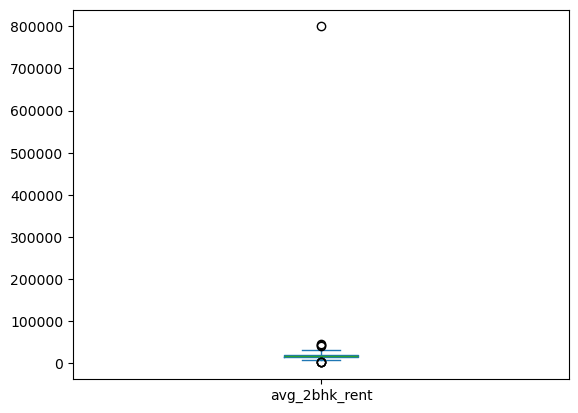

In [457]:
# 

avgRent.sort_values('avg_2bhk_rent')['avg_2bhk_rent'].plot(kind='box')


In [458]:
q1 = avgRent.avg_2bhk_rent.quantile(0.25)
q3 = avgRent.avg_2bhk_rent.quantile(0.75)

iqr = q3 - q1
lim = (3 / 2) * iqr

avgRent = avgRent.drop(
    avgRent[
        (avgRent.avg_2bhk_rent > q3 + lim) | (avgRent.avg_2bhk_rent < q1 - lim)
    ].index
)

In [459]:
# 2. Prepare the Coordinates
# KNN expects an array of [[lat1, lon1], [lat2, lon2]...]
coords_rental = avgRent[['latitude', 'longitude']].values
prices_rental = avgRent['avg_2bhk_rent'].values

In [460]:
knn = KNeighborsRegressor(n_neighbors=1, weights='distance', metric='euclidean')
knn.fit(coords_rental, prices_rental)

KNeighborsRegressor(metric='euclidean', n_neighbors=1, weights='distance')

In [461]:
train['estimated_rental_price'] = knn.predict(train[['latitude', 'longitude']].values)

test['estimated_rental_price'] = knn.predict(test[['latitude', 'longitude']].values)


In [462]:
# q1 = disCityCenter.dist_from_city.quantile(0.25)
# q3 = disCityCenter.dist_from_city.quantile(0.75)

# iqr = q3 - q1
# lim = (3 / 2) * iqr

# disCityCenter = disCityCenter.drop(
#     disCityCenter[
#         (disCityCenter.dist_from_city > q3 + lim)
#         | (disCityCenter.dist_from_city < q1 - lim)
#     ].index
# )

In [463]:
# # 2. Prepare the Coordinates
# # KNN expects an array of [[lat1, lon1], [lat2, lon2]...]
# coords_disCity = disCityCenter[['latitude', 'longitude']].values
# prices_disCity = disCityCenter['dist_from_city'].values

# knn = KNeighborsRegressor(n_neighbors=1, weights='distance', metric='euclidean')
# knn.fit(coords_disCity, prices_disCity)

# main_coords = train[['latitude', 'longitude']].values
# train['estimated_distance_city_center'] = knn.predict(main_coords)


In [464]:
# 12.9628669 77.57750899999999

def myFn(coo):
    a = coo.split(', ')
    lat = a[0]
    long = a[1]
    a = (float(lat) - 12.9628669) ** 2
    b = (float(long) - 77.57750899999999) ** 2
    return (a + b) ** 0.5
# 

train['estimated_distance_city_center'] = train.coordinates.apply(myFn)

test['estimated_distance_city_center'] = test.coordinates.apply(myFn)

### society

In [465]:
train.society.value_counts()

# societyScores = train.groupby("society")["price"].mean()
def tryToGetSocietyScore(x):
    try:
        return train.groupby("society")["price"].mean().loc[x]
    except:
        return 0

def tryToGetSocietyNumber(x):
    try:
        return train.groupby("society")["total_sqft"].count().loc[x]
    except:
        return 0


train['societyScoresNum'] =  train.society.apply(lambda x: (0 if pd.isna(x) else tryToGetSocietyNumber(x)))
train['society_score'] = train.society.apply(lambda x: (0 if pd.isna(x) else tryToGetSocietyScore(x)))

test['societyScoresNum'] = test.society.apply(lambda x: (0 if pd.isna(x) else tryToGetSocietyNumber(x)))
test['society_score'] = test.society.apply(lambda x: (0 if pd.isna(x) else tryToGetSocietyScore(x)))

In [466]:
train.societyScoresNum.describe()
train.head()
# train.groupby("society")["total_sqft"].count()
# train['societyScoresNum']


,ID,availability,location,size,society,total_sqft,bath,balcony,price,coordinates,latitude,longitude,area_type_Super_built_up,area_type_Built_up,area_type_Carpet,estimated_rental_price,estimated_distance_city_center,societyScoresNum,society_score
1,1,0,Chikka Tirupathi,4,Theanmp,2600.000000,5.000000,3.000000,120.000000,"12.8967455, 77.86674160000001",12.896745,77.866742,0,0,0,26000.000000,0.296694,7,126.428571
5,5,0,Whitefield,2,DuenaTa,1170.000000,2.000000,1.000000,38.000000,"12.9698196, 77.7499721",12.969820,77.749972,1,0,0,14981.000000,0.172603,1,38.000000
11,11,0,Whitefield,4,Prrry M,2785.000000,5.000000,3.000000,295.000000,"12.9698196, 77.7499721",12.969820,77.749972,0,0,0,14981.000000,0.172603,4,289.000000
13,13,0,Gottigere,2,NaN,1100.000000,2.000000,2.000000,40.000000,"12.856443, 77.58884479999999",12.856443,77.588845,0,1,0,11000.000000,0.107026,0,0.000000
14,14,0,Sarjapur,3,Skityer,2250.000000,3.000000,2.000000,148.000000,"12.8575579, 77.7864057",12.857558,77.786406,0,0,0,26000.000000,0.233940,1,148.000000


### standard scaling

In [467]:
# scaler = StandardScaler()

# numeric_cols = train.select_dtypes(include=[np.number]).columns
# train[numeric_cols] = scaler.fit_transform(train[numeric_cols])

In [468]:
# numeric_cols = test.select_dtypes(include=[np.number]).columns
# test[numeric_cols] = scaler.fit_transform(test[numeric_cols])

In [469]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2664 entries, 0 to 2663
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              2664 non-null   int64  
 1   availability                    2664 non-null   int64  
 2   location                        2664 non-null   object 
 3   size                            2664 non-null   int64  
 4   society                         1590 non-null   object 
 5   total_sqft                      2664 non-null   float64
 6   bath                            2664 non-null   float64
 7   balcony                         2664 non-null   float64
 8   coordinates                     2664 non-null   object 
 9   latitude                        2664 non-null   float64
 10  longitude                       2664 non-null   float64
 11  area_type_Super_built_up        2664 non-null   int64  
 12  area_type_Built_up              26

In [470]:
test.head()

,ID,availability,location,size,society,total_sqft,bath,balcony,coordinates,latitude,longitude,area_type_Super_built_up,area_type_Built_up,area_type_Carpet,estimated_rental_price,estimated_distance_city_center,societyScoresNum,society_score
0,0,0,Chamrajpet,2,NaN,650.000000,1.000000,1.000000,"12.9569869, 77.5621397",12.956987,77.562140,1,0,0,15875.000000,0.016456,0,0.000000
1,1,0,7th Phase JP Nagar,3,SrncyRe,1370.000000,2.000000,1.000000,"12.8978624, 77.58450839999999",12.897862,77.584508,1,0,0,21500.000000,0.065380,0,0.000000
2,2,0,Whitefield,3,AjhalNa,1725.000000,3.000000,2.000000,"12.9698196, 77.7499721",12.969820,77.749972,1,0,0,14981.000000,0.172603,0,0.000000
3,3,0,Jalahalli,2,NaN,1000.000000,2.000000,0.000000,"13.0454314, 77.5478699",13.045431,77.547870,0,1,0,11000.000000,0.087723,0,0.000000
4,4,0,TC Palaya,1,NaN,1350.000000,1.000000,0.000000,"13.0190631, 77.7037131",13.019063,77.703713,0,0,0,11954.000000,0.138150,0,0.000000


In [471]:
train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2122 entries, 1 to 10650
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              2122 non-null   int64  
 1   availability                    2122 non-null   int64  
 2   location                        2122 non-null   object 
 3   size                            2122 non-null   int64  
 4   society                         831 non-null    object 
 5   total_sqft                      2122 non-null   float64
 6   bath                            2122 non-null   float64
 7   balcony                         2122 non-null   float64
 8   price                           2122 non-null   float64
 9   coordinates                     2122 non-null   object 
 10  latitude                        2122 non-null   float64
 11  longitude                       2122 non-null   float64
 12  area_type_Super_built_up        2122 n

In [472]:
test.head()

,ID,availability,location,size,society,total_sqft,bath,balcony,coordinates,latitude,longitude,area_type_Super_built_up,area_type_Built_up,area_type_Carpet,estimated_rental_price,estimated_distance_city_center,societyScoresNum,society_score
0,0,0,Chamrajpet,2,NaN,650.000000,1.000000,1.000000,"12.9569869, 77.5621397",12.956987,77.562140,1,0,0,15875.000000,0.016456,0,0.000000
1,1,0,7th Phase JP Nagar,3,SrncyRe,1370.000000,2.000000,1.000000,"12.8978624, 77.58450839999999",12.897862,77.584508,1,0,0,21500.000000,0.065380,0,0.000000
2,2,0,Whitefield,3,AjhalNa,1725.000000,3.000000,2.000000,"12.9698196, 77.7499721",12.969820,77.749972,1,0,0,14981.000000,0.172603,0,0.000000
3,3,0,Jalahalli,2,NaN,1000.000000,2.000000,0.000000,"13.0454314, 77.5478699",13.045431,77.547870,0,1,0,11000.000000,0.087723,0,0.000000
4,4,0,TC Palaya,1,NaN,1350.000000,1.000000,0.000000,"13.0190631, 77.7037131",13.019063,77.703713,0,0,0,11954.000000,0.138150,0,0.000000


In [473]:
# # train.drop(['price_per_sqft'], axis=1, inplace=True)

# x = train.drop('price', axis=1)
# # y = train['price']

# x = x.select_dtypes(include= 'number')
# x = sm.add_constant(x)

# X_train, X_test, y_train, y_test = train_test_split(x, y, random_state=1, test_size = 0.2)


# # 0.389
# # 0.392


# myModel = sm.OLS(y_train, X_train).fit()
# print(myModel.summary())


# t = test.select_dtypes(include= 'number')
# t = sm.add_constant(t)


# with open('submit.csv', 'w') as f:
#     f.write('ID,price\n')
#     predictions = myModel.predict(t)
#     for idx, pred in enumerate(predictions):
#         f.write(f'{idx},{pred}\n')

In [474]:
# myModel.mse_resid ** 0.5

In [475]:
# # train.drop(['price_per_sqft'], axis=1, inplace=True)

# x = train.drop('price', axis=1)
# # y = train['price']

# x = x.select_dtypes(include= 'number')
# x = sm.add_constant(x)


# # 0.389
# # 0.392


# myModel = sm.OLS(y, x).fit()
# # print(myModel.summary())


# tt = test.select_dtypes(include= 'number')
# tt = sm.add_constant(tt)



# print("\n\n\n\n?????????????????")
# print(tt.head())

# with open('submit2.csv', 'w') as f:
#     f.write('ID,price\n')
#     predictions = myModel.predict(tt)

#     print(">>>>>>>>>>>>>>>>>>>>>>>>>>>>>")
#     for idx, pred in enumerate(predictions):
#         f.write(f'{idx},{pred}\n')

In [476]:
train.head()

,ID,availability,location,size,society,total_sqft,bath,balcony,price,coordinates,latitude,longitude,area_type_Super_built_up,area_type_Built_up,area_type_Carpet,estimated_rental_price,estimated_distance_city_center,societyScoresNum,society_score
1,1,0,Chikka Tirupathi,4,Theanmp,2600.000000,5.000000,3.000000,120.000000,"12.8967455, 77.86674160000001",12.896745,77.866742,0,0,0,26000.000000,0.296694,7,126.428571
5,5,0,Whitefield,2,DuenaTa,1170.000000,2.000000,1.000000,38.000000,"12.9698196, 77.7499721",12.969820,77.749972,1,0,0,14981.000000,0.172603,1,38.000000
11,11,0,Whitefield,4,Prrry M,2785.000000,5.000000,3.000000,295.000000,"12.9698196, 77.7499721",12.969820,77.749972,0,0,0,14981.000000,0.172603,4,289.000000
13,13,0,Gottigere,2,NaN,1100.000000,2.000000,2.000000,40.000000,"12.856443, 77.58884479999999",12.856443,77.588845,0,1,0,11000.000000,0.107026,0,0.000000
14,14,0,Sarjapur,3,Skityer,2250.000000,3.000000,2.000000,148.000000,"12.8575579, 77.7864057",12.857558,77.786406,0,0,0,26000.000000,0.233940,1,148.000000


In [477]:
train.head()


,ID,availability,location,size,society,total_sqft,bath,balcony,price,coordinates,latitude,longitude,area_type_Super_built_up,area_type_Built_up,area_type_Carpet,estimated_rental_price,estimated_distance_city_center,societyScoresNum,society_score
1,1,0,Chikka Tirupathi,4,Theanmp,2600.000000,5.000000,3.000000,120.000000,"12.8967455, 77.86674160000001",12.896745,77.866742,0,0,0,26000.000000,0.296694,7,126.428571
5,5,0,Whitefield,2,DuenaTa,1170.000000,2.000000,1.000000,38.000000,"12.9698196, 77.7499721",12.969820,77.749972,1,0,0,14981.000000,0.172603,1,38.000000
11,11,0,Whitefield,4,Prrry M,2785.000000,5.000000,3.000000,295.000000,"12.9698196, 77.7499721",12.969820,77.749972,0,0,0,14981.000000,0.172603,4,289.000000
13,13,0,Gottigere,2,NaN,1100.000000,2.000000,2.000000,40.000000,"12.856443, 77.58884479999999",12.856443,77.588845,0,1,0,11000.000000,0.107026,0,0.000000
14,14,0,Sarjapur,3,Skityer,2250.000000,3.000000,2.000000,148.000000,"12.8575579, 77.7864057",12.857558,77.786406,0,0,0,26000.000000,0.233940,1,148.000000


### data preparation for modeling

In [478]:
train.drop(['ID'], axis=1, inplace=True)
test.drop(['ID'], axis=1, inplace=True)


In [479]:
y_train = train['price']
X_train = train.drop('price', axis=1)
X_train = X_train.select_dtypes(include= 'number')

X_train.drop(['latitude', 'longitude'], axis=1, inplace=True)


In [480]:
# 80 20 split
X_train_80, X_train_20, y_train_80, y_train_20 = train_test_split(X_train, y_train, test_size = 0.2)

### xgb regressor

In [481]:


def printReport(model, X_test, y_test, predictions):
    # Calculate metrics
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    # Print the regression report
    print("--- XGBoost Regression Report ---")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R-squared (R²): {r2:.4f}")

    
    
    # Plot the importance of each feature
    plot_importance(model)
    plt.title("Feature Importance")
    plt.show()

    # Or get the raw scores as a dictionary
    importance = model.get_booster().get_score(importance_type='weight')
    print(importance)

In [482]:

# Initialize the Regressor instead of the Classifier
# xgb_model = XGBRegressor(max_depth=3, n_estimators=100, learning_rate=0.1, gamma=1)

# xgb_model = XGBRegressor(
#     gamma=0, learning_rate=0.2, max_depth=3, min_child_weight=5, n_estimators=50,
#     # subsample=0.8, colsample_bytree=0.8
#     )


xgb_model = XGBRegressor(
    gamma=0, learning_rate=0.05, max_depth=6, n_estimators=500, 
    # min_child_weight=5,
    # subsample=0.8, colsample_bytree=0.8
    )


# Fit the model
xgb_model.fit(X_train_80, y_train_80)


# xgb_model.get_params()

# Now you can predict
# predictions = xgb_model.predict(test.select_dtypes(include='number'))

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

--- XGBoost Regression Report ---
Mean Squared Error (MSE): 61.1013
Root Mean Squared Error (RMSE): 7.8167
Mean Absolute Error (MAE): 4.5311
R-squared (R²): 0.9923


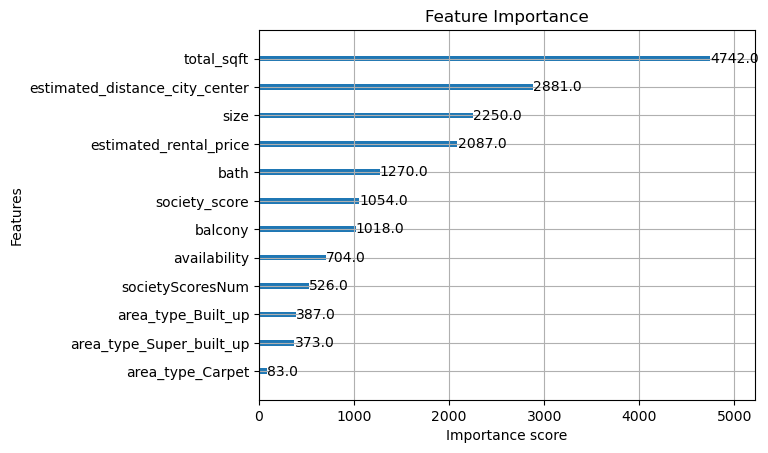

{'availability': 704.0, 'size': 2250.0, 'total_sqft': 4742.0, 'bath': 1270.0, 'balcony': 1018.0, 'area_type_Super_built_up': 373.0, 'area_type_Built_up': 387.0, 'area_type_Carpet': 83.0, 'estimated_rental_price': 2087.0, 'estimated_distance_city_center': 2881.0, 'societyScoresNum': 526.0, 'society_score': 1054.0}


'\n--- XGBoost Regression Report ---\nMean Squared Error (MSE): 961.6882\nRoot Mean Squared Error (RMSE): 31.0111\nMean Absolute Error (MAE): 15.6566\nR-squared (R²): 0.8684\n'

In [483]:
# Make predictions on your training set to see how well it fit
y_pred = xgb_model.predict(X_train_80)

printReport(xgb_model, X_train_80, y_train_80, y_pred)


"""
--- XGBoost Regression Report ---
Mean Squared Error (MSE): 961.6882
Root Mean Squared Error (RMSE): 31.0111
Mean Absolute Error (MAE): 15.6566
R-squared (R²): 0.8684
"""

--- XGBoost Regression Report ---
Mean Squared Error (MSE): 1159.3945
Root Mean Squared Error (RMSE): 34.0499
Mean Absolute Error (MAE): 15.6524
R-squared (R²): 0.7991


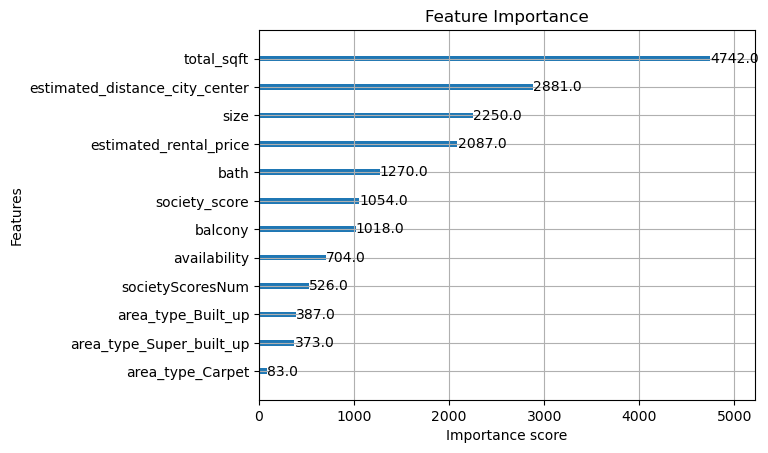

{'availability': 704.0, 'size': 2250.0, 'total_sqft': 4742.0, 'bath': 1270.0, 'balcony': 1018.0, 'area_type_Super_built_up': 373.0, 'area_type_Built_up': 387.0, 'area_type_Carpet': 83.0, 'estimated_rental_price': 2087.0, 'estimated_distance_city_center': 2881.0, 'societyScoresNum': 526.0, 'society_score': 1054.0}


'\n\n--- XGBoost Regression Report ---\nMean Squared Error (MSE): 2447.0915\nRoot Mean Squared Error (RMSE): 49.4681\nMean Absolute Error (MAE): 20.8041\nR-squared (R²): 0.7056\n\n'

In [484]:
# Make predictions on your training set to see how well it fit
y_pred = xgb_model.predict(X_train_20)

printReport(xgb_model, X_train_20, y_train_20, y_pred)


"""

--- XGBoost Regression Report ---
Mean Squared Error (MSE): 2447.0915
Root Mean Squared Error (RMSE): 49.4681
Mean Absolute Error (MAE): 20.8041
R-squared (R²): 0.7056

"""

### submission

In [485]:
tt = test.select_dtypes(include= 'number')
tt.drop(['latitude', 'longitude'], axis=1, inplace=True)

predictions = xgb_model.predict(tt.select_dtypes(include='number'))



# ValueError: feature_names mismatch: 
# ['availability', 'size', 'total_sqft', 'bath', 'balcony', 'area_type_Super_built_up', 'area_type_Built_up', 'area_type_Carpet', 'estimated_rental_price', 'estimated_distance_city_center'] 
# ['availability', 'size', 'total_sqft', 'bath', 'balcony', 'latitude', 'longitude', 'area_type_Super_built_up', 'area_type_Built_up', 'area_type_Carpet', 'estimated_rental_price', 'estimated_distance_city_center']
# training data did not have the following fields: latitude, longitude

In [486]:

with open('submit.csv', 'w') as f:
    f.write('ID,price\n')
    for idx, pred in enumerate(predictions):
        f.write(f'{idx},{pred}\n')

In [487]:
train.head()


,availability,location,size,society,total_sqft,bath,balcony,price,coordinates,latitude,longitude,area_type_Super_built_up,area_type_Built_up,area_type_Carpet,estimated_rental_price,estimated_distance_city_center,societyScoresNum,society_score
1,0,Chikka Tirupathi,4,Theanmp,2600.000000,5.000000,3.000000,120.000000,"12.8967455, 77.86674160000001",12.896745,77.866742,0,0,0,26000.000000,0.296694,7,126.428571
5,0,Whitefield,2,DuenaTa,1170.000000,2.000000,1.000000,38.000000,"12.9698196, 77.7499721",12.969820,77.749972,1,0,0,14981.000000,0.172603,1,38.000000
11,0,Whitefield,4,Prrry M,2785.000000,5.000000,3.000000,295.000000,"12.9698196, 77.7499721",12.969820,77.749972,0,0,0,14981.000000,0.172603,4,289.000000
13,0,Gottigere,2,NaN,1100.000000,2.000000,2.000000,40.000000,"12.856443, 77.58884479999999",12.856443,77.588845,0,1,0,11000.000000,0.107026,0,0.000000
14,0,Sarjapur,3,Skityer,2250.000000,3.000000,2.000000,148.000000,"12.8575579, 77.7864057",12.857558,77.786406,0,0,0,26000.000000,0.233940,1,148.000000


### tuning

In [ ]:
# hyperparameter tuning using GridSearchCV

# create a dictionary with hyperparameters and its values
# learning_rate: pass the list of boosting learning rates
# max_depth: pass the range of values as the maximum tree depth for base learners
# gamma: pass the list of minimum loss reduction values required to make a further partition on a leaf node of the tree
from sklearn.model_selection import GridSearchCV


tuning_parameters = {'learning_rate': np.arange(0.01, 1.0, 0.05).tolist(),
                     'max_depth': range(1,9),
                     'gamma': [0, 1, 2],
                     'n_estimators': [10, 25, 50, 100, 150],
                     'min_child_weight': [1, 3, 4, 5, 6, 7],
                     'subsample': np.arange(0.1, 1.0, 0.1).tolist(),
                     'colsample_bytree': np.arange(0.1, 1.0, 0.1).tolist(),
                     }

# instantiate the 'XGBRegressor' 
xgb_model = XGBRegressor()

# use GridSearchCV() to find the optimal value of the hyperparameters
# estimator: pass the XGBoost regressor model
# param_grid: pass the list 'tuned_parameters'
# cv: number of folds in k-fold i.e. here cv = 3
# scoring: pass a measure to evaluate the model on test set
xgb_grid = GridSearchCV(estimator = xgb_model, param_grid = tuning_parameters, cv = 3)

# fit the model on X_train and y_train using fit()
xgb_grid.fit(X_train, y_train)

# get the best parameters
print('Best parameters for XGBoost classifier: ', xgb_grid.best_params_, '\n')

In [ ]:
# instantiate the 'XGBClassifier'
# 'best_params_' returns the dictionary containing best parameter values and parameter name  
# 'get()' returns the value of specified parameter
xgb_grid_model = XGBRegressor(learning_rate = xgb_grid.best_params_.get('learning_rate'),
                               max_depth = xgb_grid.best_params_.get('max_depth'),
                              gamma = xgb_grid.best_params_.get('gamma'))

# use fit() to fit the model on the train set
xgb_model = xgb_grid_model.fit(X_train, y_train)

# print the performance measures for test set for the model with best parameters
print('Classification Report for test set:\n')

NameError: name 'xgb_grid' is not defined